# Regressão Logística Binária (LBR)
## Carregamento de dados
Os dados utilizados para o treinamento do modelo são derivados do estudo anterior

In [1]:
import polars as pl

# Carrega dados do parquet
df_final = pl.read_parquet('df_final_ml_features.parquet')

# Cria coluna binária Delayed: 0 se Arrival_delay <= 30, 1 se > 30
if "Arrival_delay" in df_final.columns:
    df_final = df_final.with_columns(
        (pl.col("Arrival_delay") > 30).cast(pl.Int8).alias("Delayed")
    )
    # Remove Arrival_delay se Delayed foi criado para evitar redundância
    df_final = df_final.drop("Arrival_delay")

# Converte colunas para tipos categóricos apropriados
df_final = df_final.with_columns(
    pl.col("Route_Cluster").cast(pl.Utf8).cast(pl.Categorical),
    pl.col("Day_of_week").cast(pl.Categorical),
    pl.col("Season").cast(pl.Utf8).cast(pl.Categorical),
    pl.col("Airline").cast(pl.Categorical),
    pl.col("Delayed").cast(pl.Int8)
)

print(f"✓ Dados carregados com sucesso!")
print(f"\n  Forma: {df_final.shape}")
print(f"  Colunas: {df_final.columns}")
print(f"\nPrimeiras 10 linhas:")
print(df_final.head(10))
print(f"\nTipos de dados:")
print(df_final.schema)
print(f"\nDistribuição de Delayed:")
print(df_final.select("Delayed").group_by("Delayed").agg(pl.len().alias("Count")))
print(f"\nEstatísticas básicas:")
print(df_final.describe())

✓ Dados carregados com sucesso!

  Forma: (5714008, 11)
  Colunas: ['Day_of_week', 'Season', 'Airline', 'Route_Cluster', 'Scheduled_departure_sin', 'Scheduled_departure_cos', 'Scheduled_arrival_sin', 'Scheduled_arrival_cos', 'Estimated_flight_time', 'Distance', 'Delayed']

Primeiras 10 linhas:
shape: (10, 11)
┌─────────────┬────────┬─────────┬─────────────┬───┬─────────────┬────────────┬──────────┬─────────┐
│ Day_of_week ┆ Season ┆ Airline ┆ Route_Clust ┆ … ┆ Scheduled_a ┆ Estimated_ ┆ Distance ┆ Delayed │
│ ---         ┆ ---    ┆ ---     ┆ er          ┆   ┆ rrival_cos  ┆ flight_tim ┆ ---      ┆ ---     │
│ cat         ┆ cat    ┆ cat     ┆ ---         ┆   ┆ ---         ┆ e          ┆ i64      ┆ i8      │
│             ┆        ┆         ┆ cat         ┆   ┆ f64         ┆ ---        ┆          ┆         │
│             ┆        ┆         ┆             ┆   ┆             ┆ i64        ┆          ┆         │
╞═════════════╪════════╪═════════╪═════════════╪═══╪═════════════╪════════════╪════

In [2]:
import numpy as np
# Converte para pandas uma única vez e mantém para treinamento e predição
df_pandas = df_final.to_pandas()

# Compute weights: minority class gets higher weight
w0 = 1.0                     # majority class weight
w1 = len(df_pandas) / (2 * sum(df_pandas['Delayed']))   # typical: inverse frequency scaling

df_pandas['weight'] = np.where(df_pandas['Delayed'] == 1, w1, w0)

In [3]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Define features (exclui a variável alvo 'Delayed')
features = ' + '.join(df_final.columns[:-1])

# Treina modelo de regressão logística binária
lbr_model = smf.glm(formula='Delayed ~ ' + features, data=df_pandas,
                    family=sm.families.Binomial(),
                    var_weights=df_pandas['weight']).fit()

print(f"✓ Modelo treinado com sucesso!")
print(f"  Treinado em {len(df_pandas):,} linhas")
print(f"\nResumo do Modelo:")
lbr_model.summary()

✓ Modelo treinado com sucesso!
  Treinado em 5,714,008 linhas

Resumo do Modelo:


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                Delayed   No. Observations:              5222000
Model:                            GLM   Df Residuals:                  5221969
Model Family:                Binomial   Df Model:                           30
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.7251e+06
Date:                Mon, 25 May 2026   Deviance:                   9.4502e+06
Time:                        17:29:07   Pearson chi2:                 7.33e+06
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03833
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.8462      0.030    -61.740      0.000      -1.905      -1.788
Day_of_week[T.Thu]         -0.1077      0.003    -37.966      0.000      -0.113      -0.102
Day_of_week[T.Fri]         -0.2788      0.003    -90.531      0.000      -0.285      -0.273
Day_of_week[T.Sat]         -0.0851      0.003    -29.716      0.000      -0.091      -0.079
Day_of_week[T.Sun]          0.0505      0.003     18.196      0.000       0.045       0.056
Day_of_week[T.Mon]         -0.0575      0.003    -20.376      0.000      -0.063      -0.052
Day_of_week[T.Tue]         -0.1117      0.003    -39.466      0.000      -0.117      -0.106
Season[T.spr]              -0.2161      0.002   -102.630      0.000      -0.220      -0.212
Season[T.sum]               0.0171      0.002      8.424      0.000       0.013       0.021
Season[T.aut]              -0.5512      0.003   -216.114      0.000      -0.556      -0.546
Airline[T.AA]               0.5061      0.006     84.022      0.000       0.494       0.518
Airline[T.US]               0.3384      0.007     48.501      0.000       0.325       0.352
Airline[T.DL]               0.1341      0.006     22.228      0.000       0.122       0.146
Airline[T.NK]               1.2068      0.007    163.949      0.000       1.192       1.221
Airline[T.UA]               0.7144      0.006    118.167      0.000       0.703       0.726
Airline[T.HA]              -0.4256      0.011    -38.967      0.000      -0.447      -0.404
Airline[T.B6]               0.7820      0.007    119.099      0.000       0.769       0.795
Airline[T.OO]               0.5724      0.006     95.762      0.000       0.561       0.584
Airline[T.EV]               0.6066      0.006     96.986      0.000       0.594       0.619
Airline[T.F9]               1.0314      0.008    131.570      0.000       1.016       1.047
Airline[T.WN]               0.5252      0.006     91.046      0.000       0.514       0.537
Airline[T.MQ]               0.7717      0.007    116.326      0.000       0.759       0.785
Airline[T.VX]               0.5805      0.009     63.274      0.000       0.563       0.598
Route_Cluster[T.0]          0.0220      0.002      9.364      0.000       0.017       0.027
Route_Cluster[T.2]          0.1250      0.002     55.590      0.000       0.121       0.129
Scheduled_departure_sin    -0.0100      0.003     -3.922      0.000      -0.015      -0.005
Scheduled_departure_cos     0.9806      0.019     52.724      0.000       0.944       1.017
Scheduled_arrival_sin       0.0453      0.003     17.372      0.000       0.040       0.050
Scheduled_arrival_cos      -0.1237      0.018     -6.704      0.000      -0.160      -0.088
Estimated_flight_time       0.0031    6.1e-05     50.112      0.000       0.003       0.003
Distance                   -0.0004   7.55e-06  

In [4]:
# Obtém predições do dataframe pandas usado para treinamento
predictions = lbr_model.predict(df_pandas)

# Adiciona predições de volta ao df_final alinhadas com índices de treinamento
df_final = df_final.with_columns(
    phat=pl.Series("phat", predictions.values)
)

print(f"Predições adicionadas: {df_final.shape}")
print(df_final.head())

Predições adicionadas: (5714008, 12)
shape: (5, 12)
┌─────────────┬────────┬─────────┬──────────────┬───┬──────────────┬──────────┬─────────┬──────────┐
│ Day_of_week ┆ Season ┆ Airline ┆ Route_Cluste ┆ … ┆ Estimated_fl ┆ Distance ┆ Delayed ┆ phat     │
│ ---         ┆ ---    ┆ ---     ┆ r            ┆   ┆ ight_time    ┆ ---      ┆ ---     ┆ ---      │
│ cat         ┆ cat    ┆ cat     ┆ ---          ┆   ┆ ---          ┆ i64      ┆ i8      ┆ f64      │
│             ┆        ┆         ┆ cat          ┆   ┆ i64          ┆          ┆         ┆          │
╞═════════════╪════════╪═════════╪══════════════╪═══╪══════════════╪══════════╪═════════╪══════════╡
│ Wed         ┆ win    ┆ AS      ┆ 1            ┆ … ┆ 205          ┆ 1448     ┆ 0       ┆ 0.286249 │
│ Wed         ┆ win    ┆ AA      ┆ 0            ┆ … ┆ 280          ┆ 2330     ┆ 0       ┆ 0.383659 │
│ Wed         ┆ win    ┆ US      ┆ 0            ┆ … ┆ 286          ┆ 2296     ┆ 0       ┆ 0.352232 │
│ Wed         ┆ win    ┆ AA      ┆ 0   

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score,\
    ConfusionMatrixDisplay, recall_score

def matriz_confusao(predicts, observado, cutoff):
    """Calcula e plota matriz de confusão para classificação binária"""
    values = predicts.values
    
    # Cria predições binárias com base no cutoff
    predicao_binaria = []
    for item in values:
        if item < cutoff:
            predicao_binaria.append(0)
        else:
            predicao_binaria.append(1)
    
    # Plota matriz de confusão
    cm = confusion_matrix(predicao_binaria, observado)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel('Observado')
    plt.ylabel('Predito')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.show()
    
    # Calcula métricas
    sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
    especificidade = recall_score(observado, predicao_binaria, pos_label=0)
    acuracia = accuracy_score(observado, predicao_binaria)

    # Exibe principais indicadores da matriz de confusão
    indicadores = pd.DataFrame({'Sensitividade': [sensitividade],
                                'Especificidade': [especificidade],
                                'Acurácia': [acuracia]})
    return indicadores

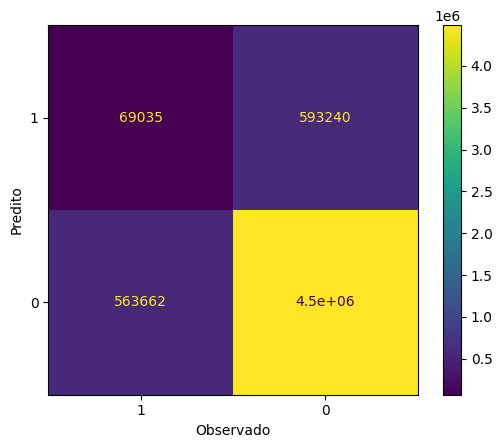

,Sensitividade,Especificidade,Acurácia
0,0.109112,0.883251,0.797532


In [6]:
# Matriz de confusão para cutoff = 0.5
# Usa df_pandas['Delayed'] para valores reais (alinhado com predições)
matriz_confusao(observado=df_pandas['Delayed'],
                predicts=predictions,
                cutoff=0.5)

Comprimento de Y verdadeiro: 5222000
Comprimento de predições: 5222000


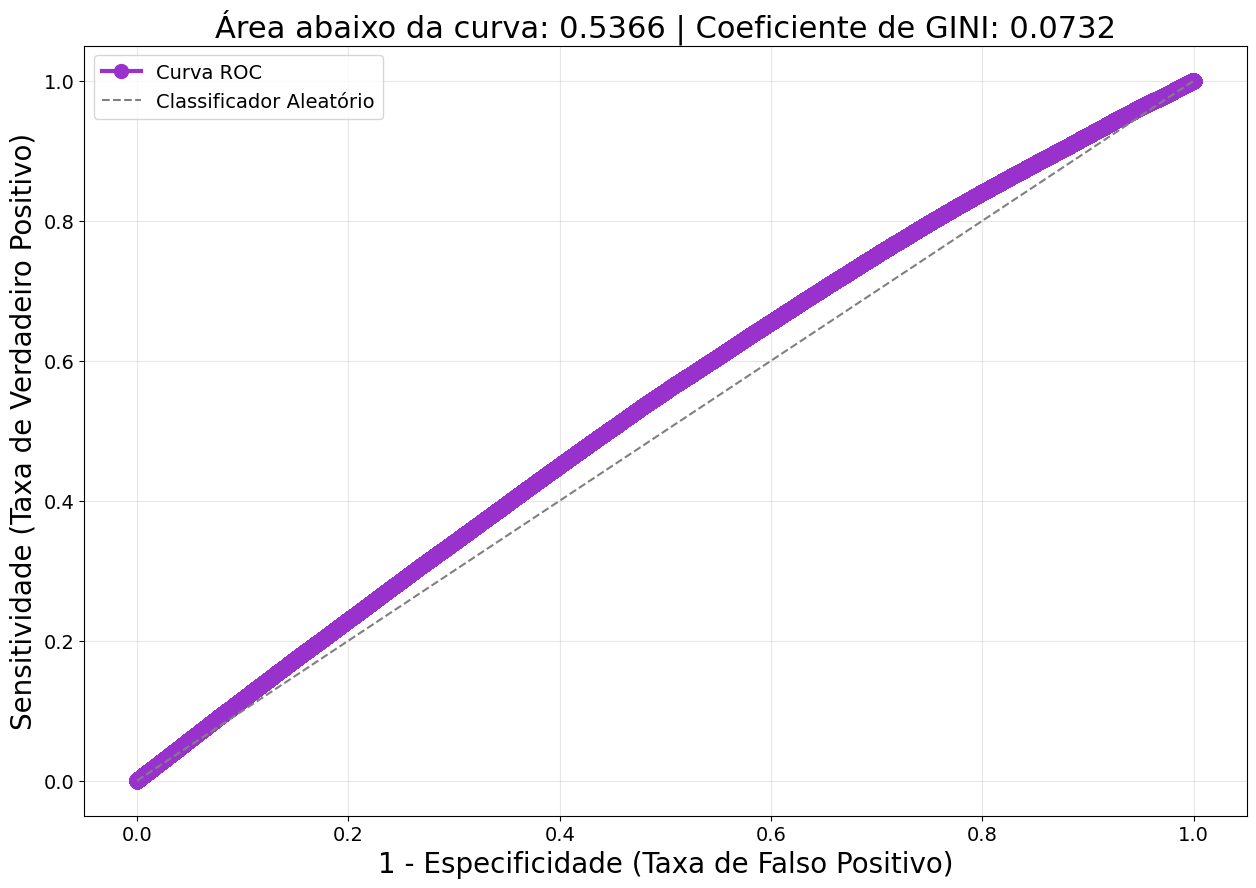


Pontuação ROC AUC: 0.5366
Coeficiente GINI: 0.0732


In [7]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Usa os valores ajustados do modelo (predições nos dados de treinamento)
# Esses estão perfeitamente alinhados com os dados de treinamento
predictions_values = lbr_model.fittedvalues
y_true = df_pandas['Delayed'].values[:len(predictions_values)]

print(f"Comprimento de Y verdadeiro: {len(y_true)}")
print(f"Comprimento de predições: {len(predictions_values)}")

# Calcula curva ROC
fpr, tpr, thresholds = roc_curve(y_true, predictions_values)
roc_auc = auc(fpr, tpr)

# Cálculo do coeficiente de GINI
gini = (roc_auc - 0.5) / 0.5

# Plotando a curva ROC
plt.figure(figsize=(15, 10))
plt.plot(fpr, tpr, marker='o', color='darkorchid', markersize=10, linewidth=3, label='Curva ROC')
plt.plot(fpr, fpr, color='gray', linestyle='dashed', label='Classificador Aleatório')
plt.title('Área abaixo da curva: %g' % round(roc_auc, 4) +
          ' | Coeficiente de GINI: %g' % round(gini, 4), fontsize=22)
plt.xlabel('1 - Especificidade (Taxa de Falso Positivo)', fontsize=20)
plt.ylabel('Sensitividade (Taxa de Verdadeiro Positivo)', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nPontuação ROC AUC: {roc_auc:.4f}")
print(f"Coeficiente GINI: {gini:.4f}")